# Lab: Sentiment Analysis with a Local Large Language Model

**Course:** COSC 442 - Artificial Intelligence  
**Estimated Time:** 60–75 minutes  

---

## Learning Objectives

By the end of this lab, you will be able to:

1. Explain what sentiment analysis is and why it matters in real-world AI applications
2. Understand the difference between rule-based, ML-based, and LLM-based approaches
3. Load and explore a real product review dataset
4. Design and iterate on prompts to extract structured sentiment predictions from a local LLM
5. Visualize *why* a model made a prediction using perturbation-based word importance
6. Evaluate model predictions against ground-truth labels using a confusion matrix
7. Extend the pipeline to perform aspect-based sentiment analysis

---

## Background

### What is Sentiment Analysis?

**Sentiment analysis** is the task of automatically identifying the emotional tone expressed in text. At its simplest, this means classifying text as **positive**, **negative**, or **neutral** — but modern systems can detect nuanced emotions, sarcasm, and opinions about specific aspects of a product or experience.

### Why Does It Matter?

Sentiment analysis is one of the most widely deployed NLP tasks in industry:

- **E-commerce:** Automatically summarizing thousands of product reviews
- **Social media monitoring:** Tracking public opinion about brands in real time
- **Finance:** Analyzing news sentiment to inform trading decisions
- **Healthcare:** Detecting distress signals in patient-written text
- **Politics:** Measuring public reaction to speeches or policy announcements

### A Brief History of Approaches

| Era | Approach | How it works | Key Limitation |
|-----|----------|-------------|----------------|
| 1990s–2000s | **Lexicon-based** | Count positive/negative words using a dictionary (e.g., VADER) | Misses context, sarcasm, domain shifts |
| 2010s | **Supervised ML** | Train a classifier (Naive Bayes, SVM, LSTM) on labeled data | Needs large labeled datasets; brittle to new domains |
| 2018+ | **Transformer fine-tuning** | Fine-tune BERT on sentiment datasets | Still requires labeled data; computationally expensive |
| 2022+ | **LLM prompting** | Ask an instruction-tuned LLM to analyze sentiment in natural language | No training data needed; flexible; can reason about context |

Today we use the **LLM prompting** approach with a model that runs on your machine.

---

## Setup

In [ ]:
# Install all required libraries (you can also run pixi install using the provided pixi.toml/pixi.lock)
# This may take 1-2 minutes on first run
%pip install transformers torch datasets pandas matplotlib scikit-learn tqdm wordcloud --quiet

In [1]:
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.notebook import tqdm
from wordcloud import WordCloud, STOPWORDS
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

warnings.filterwarnings("ignore")
print("Imports successful")

Imports successful


### Loading the Model

The cell below downloads `Llama-3.2-3B-Instruct` (~6 GB) the first time it runs. On subsequent runs it loads from a local cache — no internet needed.

> If your PC cannot run `Llama-3.2-3B-Instruct`, feel free to swap it out for a smaller model.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import notebook_login
notebook_login() # You need to request permission to the meta-llama repo https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct and generate an access token

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

print(f"Loading model '{MODEL_NAME}'...")
print("(Downloads ~6 GB on first run, then loads from cache)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,   # saves memory; use float32 if you hit issues
    device_map="auto"             # auto-selects GPU/CPU
)
model.eval()

param_count = sum(p.numel() for p in model.parameters())
print(f"\nModel loaded! Parameters: {param_count:,} ({param_count/1e6:.0f}M)")

Loading model 'meta-llama/Llama-3.2-3B-Instruct'...
(Downloads ~6 GB on first run, then loads from cache)


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.



Model loaded! Parameters: 3,212,749,824 (3213M)


### Core Inference Function

Let's write a simple function to send a prompt to the model and get a response:

In [ ]:
def generate(prompt: str, max_new_tokens: int = 100) -> str:
    """
    Run the Llama-3.2-3B-Instruct model on a prompt and return the generated text.

    Parameters
    ----------
    prompt : str
        The full input prompt.
    max_new_tokens : int
        Maximum number of tokens the model can generate in its response.
        For short structured outputs like JSON, 100-150 is sufficient.

    Returns
    -------
    str
        The model's generated response as a plain string.
    """
    device = next(model.parameters()).device

    # Format as a chat message so the model knows when to stop
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True  # adds the <|start_header_id|>assistant<|end_header_id|> marker
    )

    inputs = tokenizer(formatted, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    prompt_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][prompt_length:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()


# Quick sanity check
test = generate("Translate to French: The weather is nice today.")
print("Model test output:", test)

Model test output: Le temps est agréable aujourd'hui.


---

## Part 1: Loading and Exploring the Dataset

We will use the **Amazon Reviews 2023** dataset — a large, real-world collection of product reviews with verified star ratings. We load the *Software* category and sample 100 reviews (20 per star level) to keep runtime manageable.

The star ratings give us **ground truth labels** we can use later to evaluate our model.

In [6]:
from datasets import load_dataset

print("Loading Amazon Reviews 2023 (Software category)...")
print("Using streaming mode — only downloads the reviews we actually sample.")

raw_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Software",
    split="full",
    streaming=True,
    revision="refs/pr/27"
)

# Collect a balanced sample: 20 reviews per star rating (1 through 5)
SAMPLE_PER_STAR = 20
collected = {1: [], 2: [], 3: [], 4: [], 5: []}

for item in raw_dataset:
    rating = int(item.get("rating", 0))
    text   = (item.get("text")  or "").strip()
    title  = (item.get("title") or "").strip()

    if rating in collected and len(collected[rating]) < SAMPLE_PER_STAR and len(text) > 40:
        full_text = f"{title}. {text}" if title else text
        collected[rating].append({
            "review":      full_text[:600],   # cap length for model input
            "star_rating": rating
        })

    if all(len(v) >= SAMPLE_PER_STAR for v in collected.values()):
        break

all_reviews = [item for group in collected.values() for item in group]
df = pd.DataFrame(all_reviews).reset_index(drop=True)
df.index.name = "id"
df = df.reset_index()

print(f"\nLoaded {len(df)} reviews")
print(f"Distribution: {df['star_rating'].value_counts().sort_index().to_dict()}")
df.head()

Loading Amazon Reviews 2023 (Software category)...
Using streaming mode — only downloads the reviews we actually sample.

Loaded 100 reviews
Distribution: {1: 20, 2: 20, 3: 20, 4: 20, 5: 20}


,id,review,star_rating
0,0,Fraught with too many problems. Save your mone...,1
1,1,Nothing special. not that good a much better a...,1
2,2,don't bother...too many bugs... NO solutions....,1
3,3,App is awful. Nope. Not only did it NOT work....,1
4,4,One Star. Sadly this game crashed my phone eve...,1


### 1.1 — Star Rating Distribution

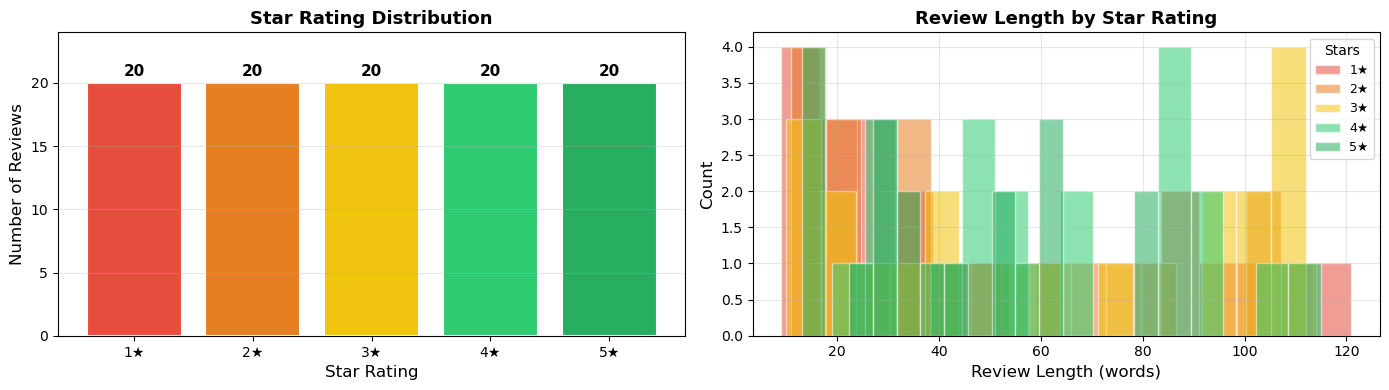

Average review length: 53 words | Longest: 121 words


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of star ratings
ax1 = axes[0]
star_counts  = df["star_rating"].value_counts().sort_index()
bar_colors   = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
bars = ax1.bar(star_counts.index, star_counts.values, color=bar_colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, star_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.set_xlabel("Star Rating", fontsize=12)
ax1.set_ylabel("Number of Reviews", fontsize=12)
ax1.set_title("Star Rating Distribution", fontweight="bold", fontsize=13)
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(["1★","2★","3★","4★","5★"])
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim(0, max(star_counts.values) + 4)

# Review length distribution by star rating
ax2 = axes[1]
df["review_length"] = df["review"].str.split().str.len()
for rating, color in zip([1,2,3,4,5], bar_colors):
    lengths = df[df["star_rating"] == rating]["review_length"]
    ax2.hist(lengths, bins=15, alpha=0.55, color=color, label=f"{rating}★", edgecolor="white")
ax2.set_xlabel("Review Length (words)", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_title("Review Length by Star Rating", fontweight="bold", fontsize=13)
ax2.legend(title="Stars", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Average review length: {df['review_length'].mean():.0f} words | Longest: {df['review_length'].max()} words")

### 1.2 — Word Clouds by Sentiment

A **word cloud** visualizes word frequency — larger words appear more often. Comparing the low-rated and high-rated clouds gives an intuition for the vocabulary differences the model will learn to detect.

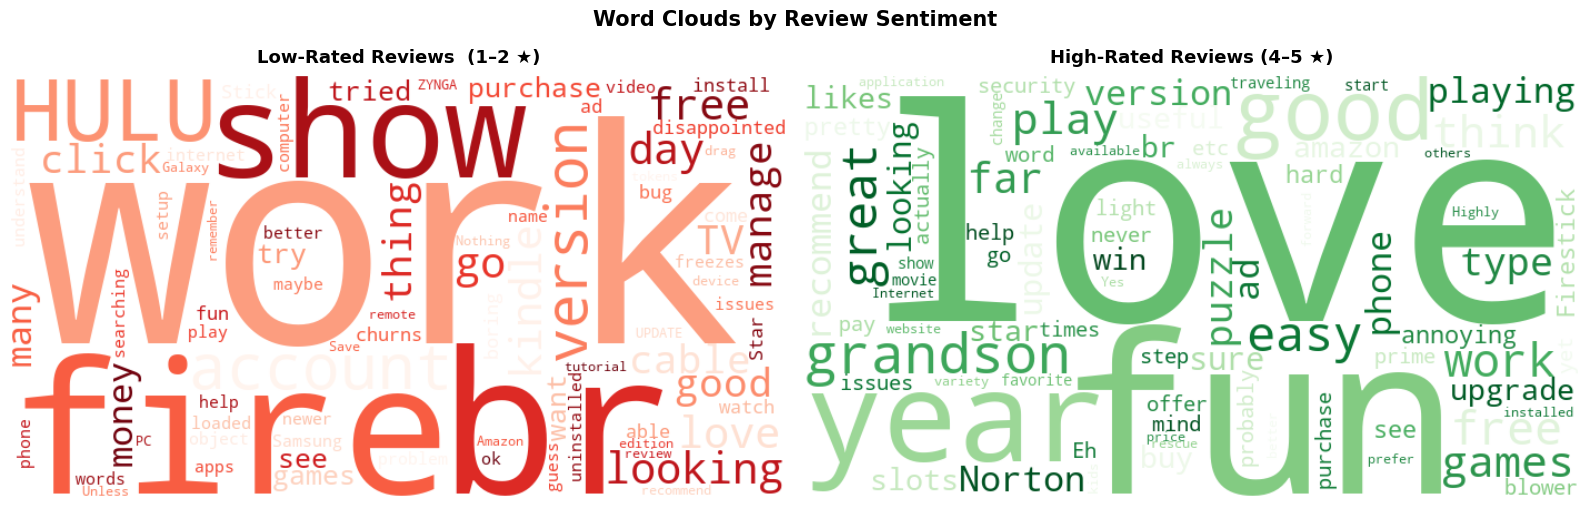

In [30]:
custom_stops = set(STOPWORDS) | {
    "software", "product", "use", "used", "using", "one", "get", "got",
    "also", "would", "could", "will", "like", "just", "really", "even",
    "though", "still", "much", "well", "back", "since", "now", "time",
    "need", "way", "every", "make", "made", "lot", "new", "old", "game", "app"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (reviews, title, cmap) in zip(axes, [
    (df[df["star_rating"] <= 2]["review"], "Low-Rated Reviews  (1–2 ★)",  "Reds"),
    (df[df["star_rating"] >= 4]["review"], "High-Rated Reviews (4–5 ★)", "Greens"),
]):
    text = " ".join(reviews.tolist())
    wc = WordCloud(
        width=700, height=380, background_color="white",
        stopwords=custom_stops, colormap=cmap,
        max_words=80, min_font_size=8, collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=13, pad=10)

plt.suptitle("Word Clouds by Review Sentiment", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> **Notice:** The positive and negative word clouds look quite different. Words like *"great", "easy", "love"* dominate positive reviews while *"error", "crash", "waste", "refund"* appear in negative ones. A simple lexicon-based classifier just counts these words. Our LLM goes further — it understands context, negation, and tone.

---

## Part 2: Building the Sentiment Pipeline

### 2.1 — Naive First Attempt

Let's start with the most obvious approach and see why it's not good enough for a pipeline:

In [18]:
sample = df[df["star_rating"] == 1].iloc[0]["review"]
print("Review:", sample[:300])
print()

naive_prompt = f'What is the sentiment of this review: "{sample[:300]}"'
print("Model output:", generate(naive_prompt))

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Review: Fraught with too many problems. Save your money and purchase a good (i.e. Norton) security for your PC. Too many issues with this version. I have not tried the newer editions since I was so burned by this one, but I do see where the latest edition is $20 cheaper than this one. So, if you are into ga

Model output: The sentiment of this review is overwhelmingly negative. The reviewer expresses frustration and disappointment with the product, stating that it is "fraught with too many problems" and that they would not recommend it. They also mention that they have been burned by a previous version of the product, which suggests that they have had a negative experience in the past. The only slightly positive comment is a backhanded one, suggesting that the newer edition is worth considering, but this is not enough to redeem the reviewer's overall


The model gives a reasonable answer in plain English — but this is useless in a pipeline. If we want to process 100 reviews and aggregate statistics, we need a **consistent, parseable output format**.

This is the central challenge of using LLMs in production: by default they produce prose. We use **prompt engineering** to control the output format.

### 2.2 — Structured Output with JSON

We will instruct the model to return a JSON object with specific fields. We also add a `Mixed` label for reviews that contain both positive and negative content — which is very common in real reviews.

In [31]:
def build_sentiment_prompt(review_text: str) -> str:
    """
    Build a structured prompt that instructs the model to return
    a JSON object with sentiment, confidence, and reason fields.
    """
    return f"""Classify the sentiment of the following product review.
Respond with only a JSON object in this exact format:
{{"sentiment": "<label>", "confidence": <score>, "reason": "<one sentence>"}}

Rules:
- sentiment must be exactly one of: Positive, Negative, Neutral, Mixed
  - Positive: overall satisfied, happy, or praising tone
  - Negative: overall dissatisfied, frustrated, or critical tone
  - Neutral: factual, no strong emotional tone
  - Mixed: contains both significant positive and negative content
- confidence must be a number between 0.0 and 1.0
- reason must be a single sentence explaining your classification
- Only respond with the given JSON format. No additional notes or thoughts are permitted. Do not under any circumstance say anything after the JSON output.

Review: "{review_text[:400]}"

JSON output:"""


# Test on examples across the star spectrum
for stars in [5, 4, 3, 2, 1]:
    review = df[df["star_rating"] == stars].iloc[0]["review"]
    raw = generate(build_sentiment_prompt(review))
    print(f"{stars}★ review: {review[:80]}...")
    print(f"   Raw output: {raw}")
    print()

5★ review: Lots of Fun. I love playing tapped out because it is fun to watch the town grow ...
   Raw output: {"sentiment": "Positive", "confidence": 0.95, "reason": "The review expresses enthusiasm and enjoyment, using words like 'Lots of Fun' and 'I love', indicating a highly positive tone."}

4★ review: I am not that good at it but my kids are. Cute game. I am not that good at it bu...
   Raw output: {"sentiment": "Positive", "confidence": 0.8, "reason": "The reviewer mentions their kids enjoy the game, indicating a positive sentiment despite the reviewer's own lack of skill."}

3★ review: discovery plus. The app works... but... in general I just don't think there is e...
   Raw output: {"sentiment": "Negative", "confidence": 0.8, "reason": "The reviewer expresses dissatisfaction with the value for money, feeling that the additional streaming costs are not justified by the available content."}

2★ review: Too many issues, maybe the newer versions are better. I found the Roxio Creato

### 2.3 — Robust JSON Parser

LLMs don't always return perfectly formed JSON — they might add extra text, use wrong quote characters, or omit fields. We need a parser with multiple fallback strategies.

In [32]:
VALID_SENTIMENTS = {"Positive", "Negative", "Neutral", "Mixed"}

def parse_sentiment_output(raw: str) -> dict:
    """
    Parse the model's raw string output into a structured dict.
    Uses three fallback strategies in order of reliability.

    Returns a dict with keys: sentiment, confidence, reason
    """
    # Strategy 1: Direct JSON parse (ideal case)
    try:
        cleaned = re.sub(r"```(?:json)?\s*|\s*```", "", raw).strip()
        data = json.loads(cleaned)
        sentiment = str(data.get("sentiment", "")).strip().capitalize()
        if sentiment in VALID_SENTIMENTS:
            return {
                "sentiment":  sentiment,
                "confidence": float(data.get("confidence", 0.5)),
                "reason":     str(data.get("reason", ""))
            }
    except (json.JSONDecodeError, ValueError):
        pass

    # Strategy 2: Extract JSON block with regex (model added extra surrounding text)
    try:
        match = re.search(r"\{.*?\}", raw, re.DOTALL)
        if match:
            data = json.loads(match.group())
            sentiment = str(data.get("sentiment", "")).strip().capitalize()
            if sentiment in VALID_SENTIMENTS:
                return {
                    "sentiment":  sentiment,
                    "confidence": float(data.get("confidence", 0.5)),
                    "reason":     str(data.get("reason", ""))
                }
    except (json.JSONDecodeError, ValueError, AttributeError):
        pass

    # Strategy 3: Keyword scan as last resort (model returned pure prose)
    raw_lower = raw.lower()
    for label in ["positive", "negative", "mixed", "neutral"]:
        if label in raw_lower:
            return {"sentiment": label.capitalize(), "confidence": 0.4,
                    "reason": "Extracted via keyword fallback"}

    return {"sentiment": "ERROR", "confidence": 0.0,
            "reason": f"Could not parse output: {raw[:80]}"}


def analyze_sentiment(review_text: str) -> dict:
    """Full pipeline: build prompt → generate → parse output."""
    prompt = build_sentiment_prompt(review_text)
    raw    = generate(prompt, max_new_tokens=120)
    return parse_sentiment_output(raw)


# Test the full pipeline
test_cases = [
    ("This software is incredible — intuitive, fast, and bug-free. Worth every penny.","Expected: Positive"),
    ("Absolute garbage. Crashed my computer twice and lost all my data.",              "Expected: Negative"),
    ("Version 3.2 was released on March 15th.",                                        "Expected: Neutral"),
    ("Great features but the UI is confusing and it crashes occasionally.",            "Expected: Mixed"),
]

print(f"{'Review (truncated)':<55} {'Sentiment':<12} {'Conf':>5}   Note")
print("-" * 90)
for text, note in test_cases:
    r = analyze_sentiment(text)
    print(f"{text[:53]:<55} {r['sentiment']:<12} {r['confidence']:>5.2f}   {note}")

Review (truncated)                                      Sentiment     Conf   Note
------------------------------------------------------------------------------------------
This software is incredible — intuitive, fast, and bu   Positive      1.00   Expected: Positive
Absolute garbage. Crashed my computer twice and lost    Negative      1.00   Expected: Negative
Version 3.2 was released on March 15th.                 Neutral       1.00   Expected: Neutral
Great features but the UI is confusing and it crashes   Mixed         0.60   Expected: Mixed


**Why three fallback strategies?**

The model is not a deterministic function with a guaranteed output format. It can produce slightly different formatting - extra explanation text, markdown fences, or capitalization differences. Production LLM pipelines always have robust parsing layers because a pipeline that crashes on 5% of inputs is not usable at scale.

---

## Part 3: Running the Full Pipeline

Now let's run every review through our pipeline. With 100 reviews and ~1–2 seconds per inference, this takes roughly **2–3 minutes**.

In [33]:
results = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Analyzing reviews"):
    result = analyze_sentiment(row["review"])
    results.append({
        "id":          row["id"],
        "review":      row["review"],
        "star_rating": row["star_rating"],
        "sentiment":   result["sentiment"],
        "confidence":  result["confidence"],
        "reason":      result["reason"],
    })

results_df = pd.DataFrame(results)
print("\nPipeline complete!")
print(f"Sentiment distribution: {results_df['sentiment'].value_counts().to_dict()}")
print(f"Errors: {(results_df['sentiment'] == 'ERROR').sum()}")
print(f"Mean confidence: {results_df['confidence'].mean():.3f}")
results_df[["star_rating", "sentiment", "confidence", "reason"]].head(8)

Analyzing reviews:   0%|          | 0/100 [00:00<?, ?it/s]


Pipeline complete!
Sentiment distribution: {'Negative': 43, 'Positive': 36, 'Mixed': 16, 'Neutral': 5}
Errors: 0
Mean confidence: 0.821


,star_rating,sentiment,confidence,reason
0,1,Negative,0.9,The reviewer expresses frustration with the pr...
1,1,Negative,0.8,The reviewer states the product is 'not that g...
2,1,Negative,0.9,The reviewer expresses strong dissatisfaction ...
3,1,Negative,0.9,The reviewer expresses strong dissatisfaction ...
4,1,Negative,0.9,The reviewer expresses frustration and disappo...
5,1,Negative,0.9,The reviewer expresses strong dissatisfaction ...
6,1,Negative,0.9,The reviewer expresses strong dislike and frus...
7,1,Mixed,0.6,The reviewer expresses both positive nostalgia...


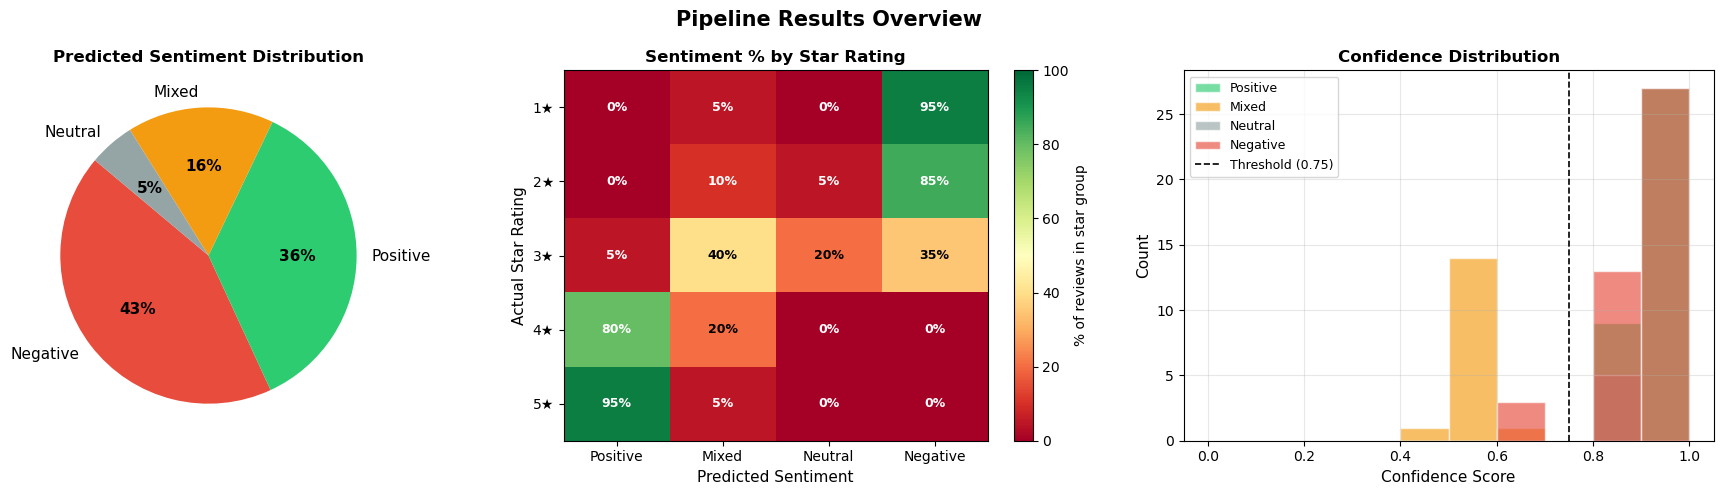

In [34]:
SENTIMENT_COLORS = {
    "Positive": "#2ecc71",
    "Negative": "#e74c3c",
    "Neutral":  "#95a5a6",
    "Mixed":    "#f39c12",
    "ERROR":    "#8e44ad"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pipeline Results Overview", fontsize=15, fontweight="bold")

# Overall distribution pie
ax1 = axes[0]
counts = results_df["sentiment"].value_counts()
colors = [SENTIMENT_COLORS.get(s, "#bdc3c7") for s in counts.index]
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=counts.index, autopct="%1.0f%%",
    colors=colors, startangle=140, textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontweight("bold")
ax1.set_title("Predicted Sentiment Distribution", fontweight="bold")

# Heatmap: star rating vs predicted sentiment
ax2 = axes[1]
sentiment_order = ["Positive", "Mixed", "Neutral", "Negative"]
cross = pd.crosstab(results_df["star_rating"], results_df["sentiment"])
for s in sentiment_order:
    if s not in cross.columns:
        cross[s] = 0
cross = cross[[s for s in sentiment_order if s in cross.columns]]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
im = ax2.imshow(cross_pct.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
ax2.set_xticks(range(len(cross_pct.columns)))
ax2.set_xticklabels(cross_pct.columns, fontsize=10)
ax2.set_yticks(range(len(cross_pct.index)))
ax2.set_yticklabels([f"{r}★" for r in cross_pct.index], fontsize=10)
ax2.set_xlabel("Predicted Sentiment", fontsize=11)
ax2.set_ylabel("Actual Star Rating", fontsize=11)
ax2.set_title("Sentiment % by Star Rating", fontweight="bold")
for i in range(len(cross_pct.index)):
    for j in range(len(cross_pct.columns)):
        val = cross_pct.values[i, j]
        ax2.text(j, i, f"{val:.0f}%", ha="center", va="center",
                 fontsize=9, fontweight="bold",
                 color="white" if val > 65 or val < 15 else "black")
plt.colorbar(im, ax=ax2, label="% of reviews in star group")

# Confidence distribution
ax3 = axes[2]
for s in sentiment_order:
    subset = results_df[results_df["sentiment"] == s]["confidence"]
    if len(subset) > 0:
        ax3.hist(subset, bins=10, range=(0,1), alpha=0.65,
                 color=SENTIMENT_COLORS[s], label=s, edgecolor="white")
ax3.axvline(0.75, color="black", linestyle="--", linewidth=1.2, label="Threshold (0.75)")
ax3.set_xlabel("Confidence Score", fontsize=11)
ax3.set_ylabel("Count", fontsize=11)
ax3.set_title("Confidence Distribution", fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

> **Reading the center heatmap:** Each row is a star level. Each cell shows what percentage of reviews at that star level received each predicted label. Ideally, 1★ reviews should be mostly `Negative` (green in the Negative column) and 5★ mostly `Positive`. Deviations — especially on 3★ reviews — reveal where the model is genuinely uncertain.

---

## Part 4: Word Importance Heatmap — *Why Did the Model Say That?*

A major criticism of LLMs is that they are **black boxes**: they give you an answer but don't explain which parts of the input drove the decision. We can approximate this using **input perturbation**.

### How Perturbation-Based Explanation Works

The idea is conceptually simple:

1. Run the model on the full review → baseline prediction + confidence
2. Remove one word at a time, re-run the model each time
3. If removing word W causes the prediction to **change** or **confidence to drop significantly**, word W was important
4. Color each word by its importance score

This technique is related to **LIME** (Local Interpretable Model-agnostic Explanations) and **SHAP** - influential methods in ML interpretability. We implement it from scratch so you can see exactly what is happening.

In [35]:
def compute_word_importance(review_text: str, max_words: int = 25) -> tuple:
    """
    Compute perturbation-based importance scores for each word in the review.

    Algorithm:
      1. Compute baseline sentiment and confidence on full text
      2. For each word i, remove it and re-run the model
      3. Importance = confidence drop if label same, or (baseline_conf + new_conf) if label flips

    Returns
    -------
    (baseline_label, baseline_conf, list_of_(word, importance_score))
    """
    words     = review_text.split()[:max_words]
    truncated = " ".join(words)

    # Baseline prediction
    base      = analyze_sentiment(truncated)
    base_lbl  = base["sentiment"]
    base_conf = base["confidence"]

    importances = []
    for i, word in enumerate(words):
        perturbed    = " ".join(words[:i] + words[i+1:])
        result       = analyze_sentiment(perturbed)
        lbl, conf    = result["sentiment"], result["confidence"]

        if lbl != base_lbl:
            # Label flipped — this word was highly influential
            importance = base_conf + conf
        else:
            # Same label — importance proportional to confidence drop
            importance = base_conf - conf

        importances.append((word, importance))

    return base_lbl, base_conf, importances


def plot_word_importance(review_text: str, max_words: int = 25):
    """Compute and render a word importance heatmap for a single review."""
    print(f"Computing word importance ({max_words} words, ~{max_words+1} model calls)...")

    base_lbl, base_conf, importances = compute_word_importance(review_text, max_words)
    print(f"Prediction: {base_lbl} (confidence: {base_conf:.2f})")

    # Normalize scores to [0, 1] for color mapping
    scores = np.array([s for _, s in importances])
    if scores.max() > scores.min():
        norm = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        norm = np.zeros_like(scores)

    cmap_name = {"Negative": "Reds", "Positive": "Greens",
                 "Mixed": "Oranges", "Neutral": "Blues"}.get(base_lbl, "Greys")
    cmap = plt.cm.get_cmap(cmap_name)

    words_per_row = 8
    n_rows        = (len(importances) + words_per_row - 1) // words_per_row
    fig, ax       = plt.subplots(figsize=(16, max(2.5, n_rows * 1.4)))
    ax.axis("off")

    label_color = SENTIMENT_COLORS.get(base_lbl, "#555")
    ax.set_title(
        f"Prediction: {base_lbl}  |  Confidence: {base_conf:.2f}\n"
        f"Color intensity = word importance  (how much the prediction changes when that word is removed)",
        fontsize=11, pad=14,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=label_color, alpha=0.15)
    )

    x_positions = np.linspace(0.03, 0.97, words_per_row)
    y_positions = np.linspace(0.82, 0.08, n_rows)

    for idx, ((word, _), n_score) in enumerate(zip(importances, norm)):
        row = idx // words_per_row
        col = idx  % words_per_row
        x   = x_positions[col]
        y   = y_positions[row] if row < len(y_positions) else 0.08
        bg  = cmap(0.2 + n_score * 0.78)
        fg  = "white" if n_score > 0.55 else "black"
        ax.text(x, y, word, fontsize=11, ha="center", va="center", color=fg,
                bbox=dict(boxstyle="round,pad=0.35", facecolor=bg, edgecolor="none", alpha=0.92))

    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.03, pad=0.02, shrink=0.4)
    cbar.set_label("Word Importance  (low → high)", fontsize=9)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(["Low", "Medium", "High"])

    plt.tight_layout()
    plt.show()

print("Word importance functions defined.")

Word importance functions defined.


NEGATIVE REVIEW:
Fraught with too many problems. Save your money and purchase a good (i.e. Norton) security for your PC. Too many issues with this version. I have not tried the newer editions since I was so burned by this one, but I do see where the latest edition is $20 cheaper than this one. So, if you are into ga

Computing word importance (24 words, ~25 model calls)...
Prediction: Negative (confidence: 0.90)


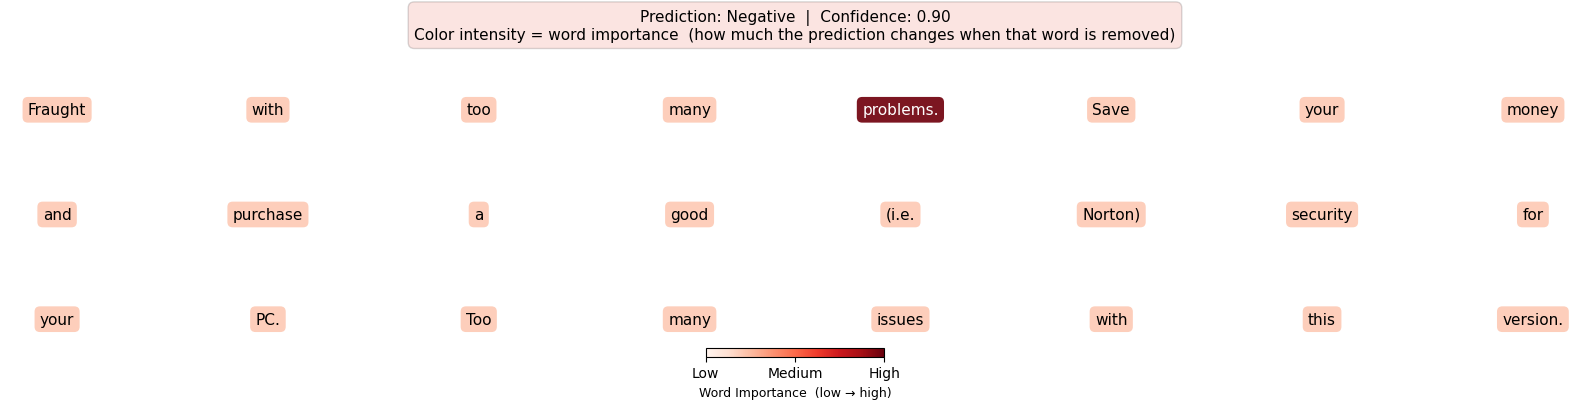

In [36]:
# Run on a clear negative review
neg_review = results_df[
    (results_df["sentiment"] == "Negative") & (results_df["star_rating"] == 1)
].iloc[0]["review"]

print("NEGATIVE REVIEW:")
print(neg_review[:300])
print()
plot_word_importance(neg_review, max_words=24)

POSITIVE REVIEW:
Lots of Fun. I love playing tapped out because it is fun to watch the town grow by earning money and buying buildings.  I love helping my neighbors, too.

Computing word importance (24 words, ~25 model calls)...
Prediction: Positive (confidence: 0.90)


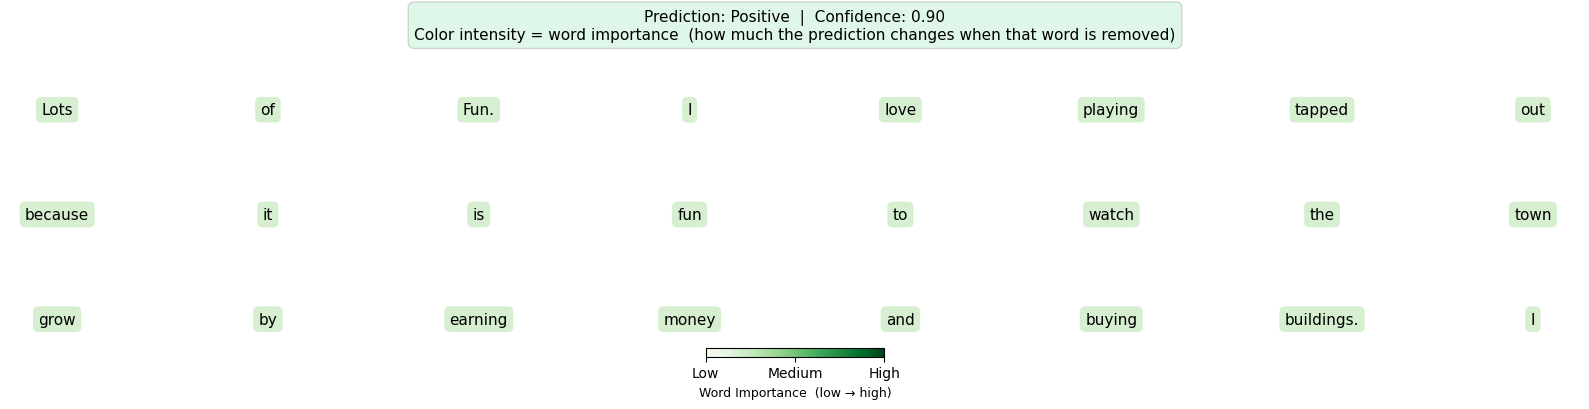

In [37]:
# Run on a clear positive review
pos_review = results_df[
    (results_df["sentiment"] == "Positive") & (results_df["star_rating"] == 5)
].iloc[0]["review"]

print("POSITIVE REVIEW:")
print(pos_review[:300])
print()
plot_word_importance(pos_review, max_words=24)

> **What to look for:** Highly colored words are the ones the model relies on most. Are they the words you would expect? Do any surprising words appear highly important? When a model misclassifies a review, the heatmap can reveal *why* — perhaps an unusual word pattern or a negation the model failed to handle.

---

## Part 5: Evaluation Against Ground Truth

We have star ratings for every review. Let's convert them to sentiment labels and measure how well the model actually performs.

### 5.1 — Mapping Stars to Labels

In [38]:
def stars_to_sentiment(stars: int) -> str:
    """
    Convert a 1-5 star rating to a coarse sentiment label.
    Note: This is a simplification. A 3-star review might be Mixed,
    but we treat it as Neutral for evaluation purposes.
    """
    if stars <= 2:  return "Negative"
    elif stars == 3: return "Neutral"
    else:            return "Positive"


results_df["ground_truth"] = results_df["star_rating"].apply(stars_to_sentiment)

# For evaluation, collapse "Mixed" predictions to "Neutral"
# (a 3-star review is the closest star-equivalent to a mixed opinion)
results_df["predicted_collapsed"] = results_df["sentiment"].replace("Mixed", "Neutral")

# Filter out parse errors
eval_df = results_df[results_df["sentiment"] != "ERROR"].copy()
print(f"Evaluating on {len(eval_df)} reviews ({(results_df['sentiment']=='ERROR').sum()} errors excluded)")

Evaluating on 100 reviews (0 errors excluded)


### 5.2 — Confusion Matrix

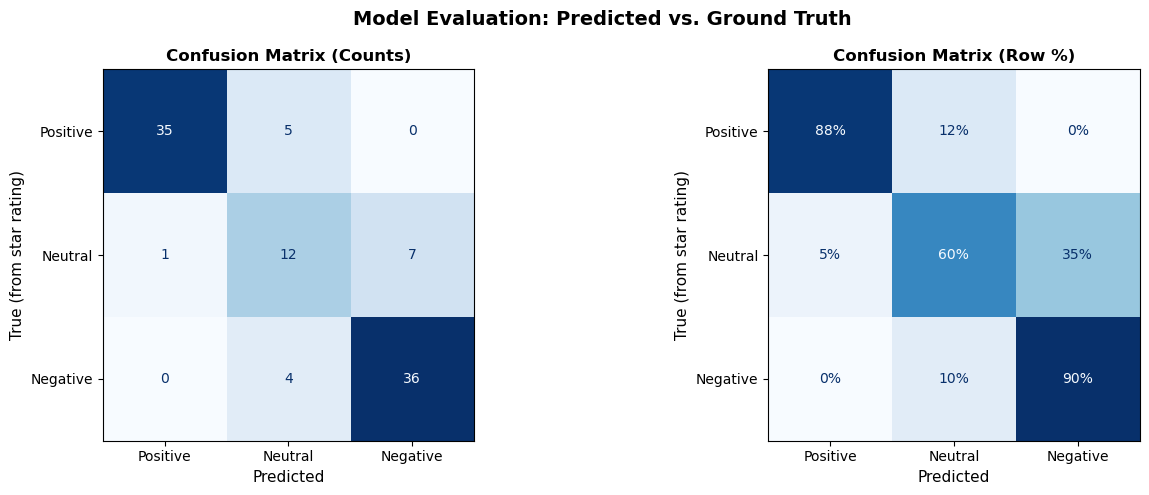

=== Classification Report ===
              precision    recall  f1-score   support

    Positive       0.97      0.88      0.92        40
     Neutral       0.57      0.60      0.59        20
    Negative       0.84      0.90      0.87        40

    accuracy                           0.83       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.84      0.83      0.83       100



In [39]:
label_order = ["Positive", "Neutral", "Negative"]
y_true = eval_df["ground_truth"].tolist()
y_pred = eval_df["predicted_collapsed"].tolist()

cm = confusion_matrix(y_true, y_pred, labels=label_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=label_order).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True (from star rating)", fontsize=11)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=label_order).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".0%")
axes[1].set_title("Confusion Matrix (Row %)", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True (from star rating)", fontsize=11)

plt.suptitle("Model Evaluation: Predicted vs. Ground Truth", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, labels=label_order, zero_division=0))

### 5.3 — Error Analysis

In [40]:
# Find the most interesting errors: Positive/Negative flips
big_errors = eval_df[
    ((eval_df["ground_truth"] == "Positive") & (eval_df["predicted_collapsed"] == "Negative")) |
    ((eval_df["ground_truth"] == "Negative") & (eval_df["predicted_collapsed"] == "Positive"))
].copy()

print(f"Major errors (Positive ↔ Negative flips): {len(big_errors)}")
print()

show = big_errors.head(5) if len(big_errors) > 0 else \
       eval_df[eval_df["ground_truth"] != eval_df["predicted_collapsed"]].head(5)

for _, row in show.iterrows():
    print(f"  Stars: {row['star_rating']}★ | Truth: {row['ground_truth']} | Predicted: {row['predicted_collapsed']}")
    print(f"  Review: {row['review'][:220]}")
    print(f"  Model reason: {row['reason']}")
    print()

Major errors (Positive ↔ Negative flips): 0

  Stars: 1★ | Truth: Negative | Predicted: Neutral
  Review: Loved this back in the day. But unfortunately you can’t play it on newer versions of computers.  We love it so much with our son thought we would try it with our grandson.
  Model reason: The reviewer expresses both positive nostalgia and a negative limitation of the product's compatibility with newer computers.

  Stars: 2★ | Truth: Negative | Predicted: Neutral
  Review: It's ok, could be better. For the amount of money, the app is good. BUT the interface leaves a lot to be desired. I have it for Roku so not sure if it's the same on each platform. When doing certain things like searching
  Model reason: The reviewer mentions both positive comments (it's ok, for the amount of money it's good) and negative comments (interface leaves a lot to be desired, frustrating search experience) about the app.

  Stars: 2★ | Truth: Negative | Predicted: Neutral
  Review: I love America and lov

> **Discussion:** Error analysis is one of the most important steps in any ML project. Before trying to improve a model, you need to understand *what kind* of errors it makes. Are the errors on genuinely ambiguous reviews? Could the star rating itself be an unreliable ground truth — for instance, a 3-star review that is actually very mixed rather than neutral?

---

## Student Task: Aspect-Based Sentiment Analysis

### Background

So far our pipeline assigns a **single overall sentiment** to each review. But real product reviews often express opinions about *multiple aspects* simultaneously. Consider:

> *"The software itself is excellent and intuitive, but the pricing is outrageous and customer support took 3 weeks to respond."*

Overall: **Mixed** — but broken down:
- Quality → **Positive**
- Price → **Negative**
- Customer Service → **Negative**

**Aspect-Based Sentiment Analysis (ABSA)** extracts per-aspect opinions. This is far more actionable for businesses — instead of "customers are mixed", it tells you *specifically what to fix*.

### Your Task

You will extend the pipeline to perform ABSA across four aspects:
- `quality` — product quality, reliability, functionality
- `price` — value for money, cost, pricing
- `ease_of_use` — usability, interface, learning curve
- `customer_service` — support, response time, refunds

---

### Step 1 — Write the ABSA Prompt

Complete `build_absa_prompt` below. The model should return a JSON object with a label for each aspect. If an aspect is not mentioned in the review, return `null` for that aspect.

In [ ]:
def build_absa_prompt(review_text: str) -> str:
    """
    TODO: Write a prompt that instructs the model to return a JSON object
    with sentiment labels for these four aspects:
        quality, price, ease_of_use, customer_service

    Each value should be one of: "Positive", "Negative", "Neutral", or null
    (null means the aspect was not mentioned in the review).
    Also include an "overall" field with the overall sentiment label.

    Expected output format:
    {
      "quality": "Positive",
      "price": "Negative",
      "ease_of_use": null,
      "customer_service": null,
      "overall": "Mixed"
    }
    """
    # YOUR CODE HERE
    prompt = ""
    return prompt


# Test your prompt on a few hand-crafted examples where you know the answer
test_reviews = [
    "The software is fantastic and very easy to learn, but the subscription price is way too high.",
    "Crashed twice this week. Support was useless. Never buying from this company again.",
    "Great value for the price. Does exactly what I need.",
]

for review in test_reviews:
    prompt = build_absa_prompt(review)
    if prompt:
        raw = generate(prompt, max_new_tokens=150)
        print(f"Review: {review[:80]}")
        print(f"Output: {raw}")
        print()
    else:
        print("Prompt not yet implemented — complete Step 1 first.")
        break

### Step 2 — Write the ABSA Parser

Write a parser that extracts aspect sentiments from the model's raw output. Use the `parse_sentiment_output` function from Part 2 as a reference.

In [ ]:
ASPECTS = ["quality", "price", "ease_of_use", "customer_service"]

def parse_absa_output(raw: str) -> dict:
    """
    TODO: Parse the model's raw output into a dict with keys:
        quality, price, ease_of_use, customer_service, overall

    Each aspect value should be "Positive", "Negative", "Neutral", or None.
    Handle malformed JSON gracefully — return None for any aspect you cannot parse.

    Hint: Adapt parse_sentiment_output from Part 2. The same three-strategy
    approach (direct parse → regex extraction → keyword scan) applies here.
    """
    # YOUR CODE HERE
    return {aspect: None for aspect in ASPECTS + ["overall"]}


def analyze_aspects(review_text: str) -> dict:
    """Full ABSA pipeline: build prompt → generate → parse."""
    prompt = build_absa_prompt(review_text)
    raw    = generate(prompt, max_new_tokens=150)
    return parse_absa_output(raw)


# Quick test
result = analyze_aspects("Great software, terrible price, support never replied.")
print("Test result:", result)

### Step 3 — Run ABSA on the Full Dataset

Run `analyze_aspects` on every review in `results_df` and store the results in `absa_df`.

In [ ]:
# TODO: Run analyze_aspects on every row in results_df.
# Store results in absa_df with columns:
#   id, review, star_rating, quality, price, ease_of_use, customer_service, overall
# Use tqdm to show progress (as in Part 3).

absa_results = []

# YOUR CODE HERE

absa_df = pd.DataFrame(absa_results)
print(absa_df.head())

### Step 4 — Visualize Aspect Sentiment

Create a visualization that shows, for each aspect, the breakdown of Positive / Neutral / Negative sentiment among reviews that *mentioned* that aspect. Include the count of reviews mentioning each aspect.

In [ ]:
# TODO: Create a visualization of per-aspect sentiment.
#
# Requirements:
#   - Only include reviews where the aspect is not None
#   - Show Positive / Neutral / Negative percentages per aspect
#   - Include a title, axis labels, and a legend or colorbar
#   - Print how many reviews mentioned each aspect
#
# Suggested chart types: grouped bar chart or stacked bar chart

# YOUR CODE HERE
pass

### Step 5 — Reflection

Answer the following questions by editing this cell (double-click to edit):

1. Which aspect received the most **negative** sentiment? Does this match what you observed when reading the reviews?

2. Which aspect was mentioned **least often**? Why might customers rarely comment on it?

3. Compare the ABSA `overall` field to the original `sentiment` from Part 3. Do they agree? For reviews where they disagree, which do you trust more and why?

4. What are **two limitations** of the perturbation-based word importance method? How might you improve it?

5. If this pipeline were deployed for a real software company, what would you change or add before going to production?

---

**Your answers:**

1. 

2. 

3. 

4. 

5. 

---

## Submission Checklist

Before submitting, confirm all of the following:

- [ ] All cells in Parts 1–5 run without errors *(Kernel → Restart & Run All to verify)*
- [ ] `build_absa_prompt` returns a working prompt (Step 1)
- [ ] `parse_absa_output` correctly extracts aspect labels from JSON (Step 2)
- [ ] ABSA pipeline runs successfully on the full dataset (Step 3)
- [ ] Aspect sentiment visualization is complete with title and labels (Step 4)
- [ ] All five reflection questions are answered in Step 5
- [ ] Notebook saved and submitted to Canvas